In [1]:
# Necessary library import
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss
warnings.filterwarnings('ignore')
#from save_score import save_accuracy_score
#from model_training import train_base_model, measure_time

#**Requirements**
**Set the dataset directory on Google Drive as:**
```plaintext
MyDrive
|--web-attack-detection/
|        |--datasets/   
|        |        |-- safe_reduced_and_malicious_balanced/  
|        |        |          |-- X_train.csv
|        |        |          |-- X_Val.csv
|        |        |          |-- X_test.csv
|        |        |          |-- y_train.csv
|        |        |          |-- y_Val.csv
|        |        |          |-- y_test.csv
|
|
|        |        |-- safe_same_and_malicious_balanced/  
|        |        |          |-- X_train.csv
|        |        |          |-- X_Val.csv
|        |        |          |-- X_test.csv
|        |        |          |-- y_train.csv
|        |        |          |-- y_Val.csv
|        |        |          |-- y_test.csv
```
\
\
### Use **" %%time "** in the begining in every cells where the trainng operations & parameter tuning operations will performed. for example you can check the decision tree training code.

In [2]:
# Add these imports if missing
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def plot_tree_learning_curves(multi_output_model, X_train, y_train, X_val, y_val, target_idx):
    """Plot accuracy curves for Decision Tree depth progression"""
    train_acc = []
    val_acc = []

    # Get base model parameters from FIRST estimator
    base_model = multi_output_model.estimators_[target_idx]
    base_params = {
        'min_samples_split': base_model.min_samples_split,
        'min_samples_leaf': base_model.min_samples_leaf,
        'random_state': base_model.random_state
    }

    # Vary max_depth from 1 to 30
    depths = range(1, 31)

    for depth in depths:
        # Create new model with current depth
        temp_model = DecisionTreeClassifier(
            max_depth=depth,
            **base_params
        )
        temp_model.fit(X_train, y_train.iloc[:, target_idx])

        # Record accuracies
        train_acc.append(accuracy_score(y_train.iloc[:, target_idx], temp_model.predict(X_train)))
        val_acc.append(accuracy_score(y_val.iloc[:, target_idx], temp_model.predict(X_val)))

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(depths, train_acc, 'b-', label='Training Accuracy')
    plt.plot(depths, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'Decision Tree Learning Curves ({y_train.columns[target_idx]})')
    plt.xlabel('Tree Depth')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
# Check if function exists
try:
    plot_tree_learning_curves
    print("Function is defined!")
except NameError:
    print("Function NOT defined - rerun the cell with the function definition.")

Function is defined!


### Helper Functions

In [4]:
def train_base_model(model, name, X_train, y_train, X_test, y_test):
    """ Train the model and print the training and test accuracy """
    """ Print the training and test accuracy of the model """
    model = MultiOutputClassifier(model)
    model.fit(X_train, y_train)

    train = model.predict(X_train)
    test = model.predict(X_test)

    train_acc1 = accuracy_score(y_train['Attack Type'], train[:,0])
    train_acc2 = accuracy_score(y_train['status'], train[:,1])
    test_acc1 = accuracy_score(y_test['Attack Type'], test[:,0])
    test_acc2 = accuracy_score(y_test['status'], test[:,1])

    print(f"{name} Train Accuracy- Attack Type: {train_acc1:.4}, Status: {train_acc2:.4}, Average: {((train_acc1+train_acc2)/2):.4}")
    print(f"{name} Test Accuracy- Attack Type: {test_acc1:.4}, Status: {test_acc2:.4}, Average: {((test_acc1+test_acc2)/2):.4}")

    def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name="Model"):
      """Enhanced evaluation with validation set metrics"""
    # Get predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # Helper function to calculate metrics
    def print_metrics(y_true, y_pred, dataset_name):
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)

        if cm.shape == (2, 2):  # Binary classification
            TN, FP, FN, TP = cm.ravel()
            print(f"{dataset_name} Metrics:")
            print(f"Accuracy: {acc:.4f}")
            print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")
        else:  # Multi-class (Attack Type)
            print(f"{dataset_name} Multi-class Accuracy: {acc:.4f}")

    # Training set evaluation
    print("\n" + "="*60)
    print(f"{name} - Training Set Evaluation")
    print_metrics(y_train['status'], train_pred[:, 1], "Training Binary (Status)")
    print_metrics(y_train['Attack Type'], train_pred[:, 0], "Training Multi-class (Attack Type)")

    # Validation set evaluation (critical missing part)
    print("\n" + "="*60)
    print(f"{name} - Validation Set Evaluation")
    print_metrics(y_val['status'], val_pred[:, 1], "Validation Binary (Status)")
    print_metrics(y_val['Attack Type'], val_pred[:, 0], "Validation Multi-class (Attack Type)")

    # Test set evaluation
    print("\n" + "="*60)
    print(f"{name} - Test Set Evaluation")
    print_metrics(y_test['status'], test_pred[:, 1], "Test Binary (Status)")
    print_metrics(y_test['Attack Type'], test_pred[:, 0], "Test Multi-class (Attack Type)")

def measure_time(sec, name):
    """ Measure the time taken for training the model """
    hours, rem = divmod(sec, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"{name} Training Time: {int(hours)}h {int(minutes)}m {int(seconds)}s")

def perform_hyperparameter_tuning(model, parameters, X_train, y_train):
    """ Perform hyperparameter tuning on the model """
    """ Return the best model and best parameters """
    model = MultiOutputClassifier(model)
    grid_search = GridSearchCV(
        estimator= model,
        param_grid=parameters,
        cv=5,
        scoring='accuracy',
        verbose=3,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print("\nBest Parameters:", best_params)
    return best_model, best_params

def check_metrics(model, name, X_train, y_train, X_val, y_val, X_test, y_test):
    """ Check the metrics of the model """
    """ It'll print the training, validation and test accuracy of the model
        It'll also print the classification report for multi-class and binary classification
        It'll also print the confusion matrix for multi-class and binary classification
    """
    train = model.predict(X_train)
    val = model.predict(X_val)
    test = model.predict(X_test)

    train_acc1 = accuracy_score(y_train['Attack Type'], train[:,0])
    train_acc2 = accuracy_score(y_train['status'], train[:,1])
    val_acc1 = accuracy_score(y_val['Attack Type'], val[:,0])
    val_acc2 = accuracy_score(y_val['status'], val[:,1])
    test_acc1 = accuracy_score(y_test['Attack Type'], test[:,0])
    test_acc2 = accuracy_score(y_test['status'], test[:,1])

    print(f"{name} Train Accuracy- Attack Type: {train_acc1:.4}, Status: {train_acc2:.4}, Average: {((train_acc1+train_acc2)/2):.4}")
    print(f"{name} Validation Accuracy- Attack Type: {val_acc1:.4}, Status: {val_acc2:.4}, Average: {((val_acc1+val_acc2)/2):.4}")
    print(f"{name} Test Accuracy- Attack Type: {test_acc1:.4}, Status: {test_acc2:.4}, Average: {((test_acc1+test_acc2)/2):.4}")

    # multi-class classification report
    print("\nClassification Report for multi-class classification")
    print(classification_report(y_test['Attack Type'], test[:,0]))

    # binary classification report
    print("\nClassification Report for binary classification")
    print(classification_report(y_test['status'], test[:,1]))

    attack_cm = confusion_matrix(y_test['Attack Type'], test[:, 0])
    label_cm = confusion_matrix(y_test['status'], test[:, 1])

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    sns.heatmap(attack_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Multi-class Classification Confusion Matrix')
    axes[0].set_xlabel('Predicted Result')
    axes[0].set_ylabel('Actual Result')

    sns.heatmap(label_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Binary Classification Confusion Matrix')
    axes[1].set_xlabel('Predicted Result')
    axes[1].set_ylabel('Actual Result')

    plt.tight_layout()
    plt.show()

def plot_tree_learning_curves(multi_output_model, X_train, y_train, X_val, y_val, target_idx):
     """Plot accuracy curves for Decision Tree depth progression"""
     train_acc = []
     val_acc = []

    # Get base model parameters from FIRST estimator
     base_model = multi_output_model.estimators_[target_idx]
     base_params = {
        'min_samples_split': base_model.min_samples_split,
        'min_samples_leaf': base_model.min_samples_leaf,
        'random_state': base_model.random_state
     }

    # Vary max_depth from 1 to 30
     depths = range(1, 31)

     for depth in depths:
         # Create new model with current depth
         temp_model = DecisionTreeClassifier(
            max_depth=depth,
            **base_params
        )
         temp_model.fit(X_train, y_train.iloc[:, target_idx])

        # Record accuracies
         train_acc.append(accuracy_score(y_train.iloc[:, target_idx], temp_model.predict(X_train)))
         val_acc.append(accuracy_score(y_val.iloc[:, target_idx], temp_model.predict(X_val)))

    # Plotting
     plt.figure(figsize=(10, 6))
     plt.plot(depths, train_acc, 'b-', label='Training Accuracy')
     plt.plot(depths, val_acc, 'r-', label='Validation Accuracy')
     plt.title(f'Decision Tree Learning Curves ({y_train.columns[target_idx]})')
     plt.xlabel('Tree Depth')
     plt.ylabel('Accuracy')
     plt.legend()
     plt.grid(True)
     plt.show()


def plot_rf_learning_curves(model, X_train, y_train, X_val, y_val, target_idx):
    """Plot learning curves for Random Forest (n_estimators vs accuracy)"""
    train_acc = []
    val_acc = []

    # Get base parameters
    base_model = model.estimators_[target_idx]
    base_params = {
        'max_depth': base_model.max_depth,
        'min_samples_split': base_model.min_samples_split,
        'max_features': base_model.max_features,
        'random_state': 42
    }

    # Vary n_estimators
    n_estimators_range = [10, 50, 100, 150]

    for n in n_estimators_range:
        temp_model = RandomForestClassifier(
            n_estimators=n,
            **base_params
        )
        temp_model.fit(X_train, y_train.iloc[:, target_idx])

        train_acc.append(accuracy_score(y_train.iloc[:, target_idx], temp_model.predict(X_train)))
        val_acc.append(accuracy_score(y_val.iloc[:, target_idx], temp_model.predict(X_val)))

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_range, train_acc, 'b-o', label='Training Accuracy')
    plt.plot(n_estimators_range, val_acc, 'r-o', label='Validation Accuracy')
    plt.title(f'RF Learning Curves ({y_train.columns[target_idx]})')
    plt.xlabel('Number of Trees')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


*****
# Model Training on Dataset Version 1 (safe_reduced_malicious_balanced)
**Dataset Details:**
- 1522380 samples
- 30 features
- 2 targets
  - 7 different class (1 safe, 6 diffrent malicious)
  - binary class (0-safe, 1-malicous)

In [18]:
# Load Dataset Version 1
X_train = pd.read_csv("/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_reduced_and_malicious_balanced/X_train.csv")
X_val = pd.read_csv("/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_reduced_and_malicious_balanced/X_val.csv")
X_test = pd.read_csv("/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_reduced_and_malicious_balanced/X_test.csv")
y_train = pd.read_csv("/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_reduced_and_malicious_balanced/y_train.csv")
y_val = pd.read_csv("/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_reduced_and_malicious_balanced/y_val.csv")
y_test = pd.read_csv("/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_reduced_and_malicious_balanced/y_test.csv")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Train base model on training set and evaluate on Test set. (Decision Tree, Random Forest, Naive Bayes)
printing the Training and Test set accuracy for each models.

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
  start = time.time()
  train_base_model(model, name, X_train, y_train, X_test, y_test)
  end = time.time()
  measure_time((end-start), name)

Decision Tree Train Accuracy- Attack Type: 0.9955, Status: 0.9956, Average: 0.9955
Decision Tree Test Accuracy- Attack Type: 0.9906, Status: 0.9936, Average: 0.9921
Decision Tree Training Time: 0h 1m 38s
Random Forest Train Accuracy- Attack Type: 0.9954, Status: 0.9956, Average: 0.9955
Random Forest Test Accuracy- Attack Type: 0.9913, Status: 0.9942, Average: 0.9928
Random Forest Training Time: 0h 16m 32s
Naive Bayes Train Accuracy- Attack Type: 0.616, Status: 0.8595, Average: 0.7377
Naive Bayes Test Accuracy- Attack Type: 0.6167, Status: 0.8608, Average: 0.7387
Naive Bayes Training Time: 0h 0m 4s


## Decision Tree

In [ ]:
%%time
#performing hyperparameter tuning for Decision Tree model
dt_param_grid = {
    'estimator__max_depth': [10, 20, 30, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

dt_model, dt_best_params = perform_hyperparameter_tuning(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}
CPU times: user 1min 39s, sys: 12.6 s, total: 1min 51s
Wall time: 2h 7min 41s


In [ ]:
# 1. Import joblib
import joblib

# 2. Save the model
joblib.dump(dt_model, "/content/drive/MyDrive/web-attack-detection/decision_tree_classifier.pkl")
print("Model saved successfully!")

Decison Tree Train Accuracy- Attack Type: 0.9763, Status: 0.973, Average: 0.9746
Decison Tree Validation Accuracy- Attack Type: 0.9758, Status: 0.9727, Average: 0.9743
Decison Tree Test Accuracy- Attack Type: 0.9757, Status: 0.9728, Average: 0.9742

Classification Report for multi-class classification
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     53867
           1       0.96      1.00      0.98     28968
           2       0.99      0.96      0.98     28934
           3       1.00      1.00      1.00     29109
           4       1.00      0.97      0.99     29364
           5       0.99      0.99      0.99     29047
           6       0.92      0.99      0.95     29068

    accuracy                           0.98    228357
   macro avg       0.98      0.98      0.98    228357
weighted avg       0.98      0.98      0.98    228357


Classification Report for binary classification
              precision    recall  f1-score   suppo

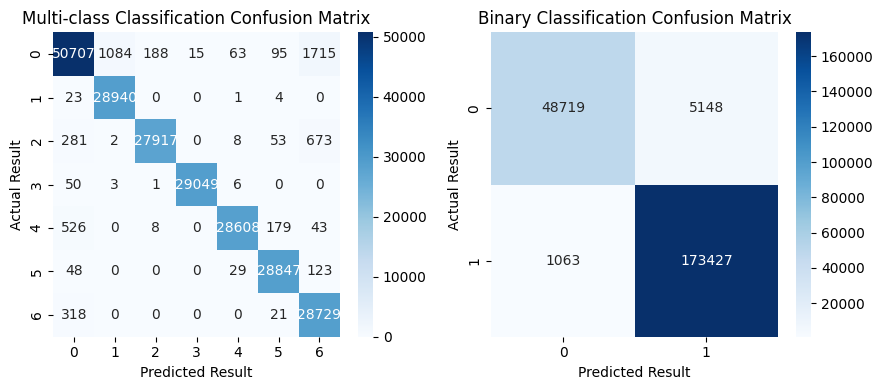

In [ ]:
check_metrics(dt_model, "Decison Tree", X_train, y_train, X_val, y_val, X_test, y_test) # check for metrics


Decision Tree Training Accuracy Curves (Version 1)


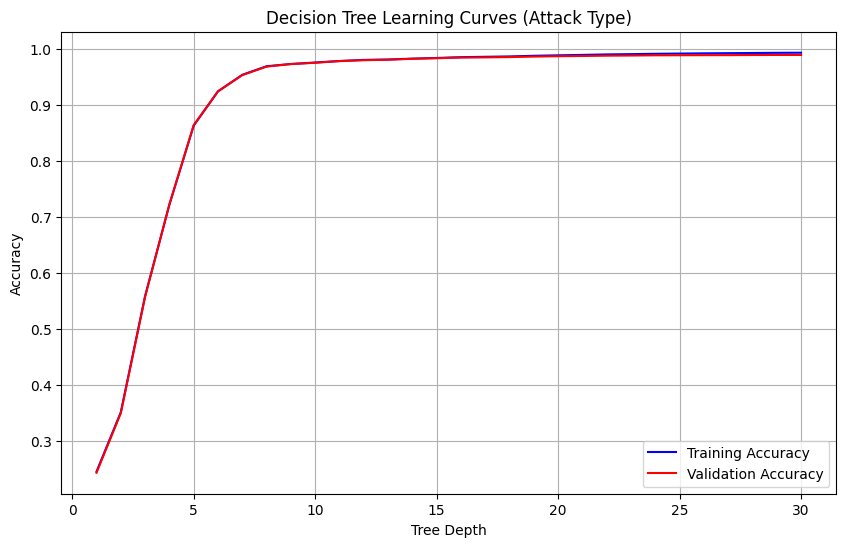

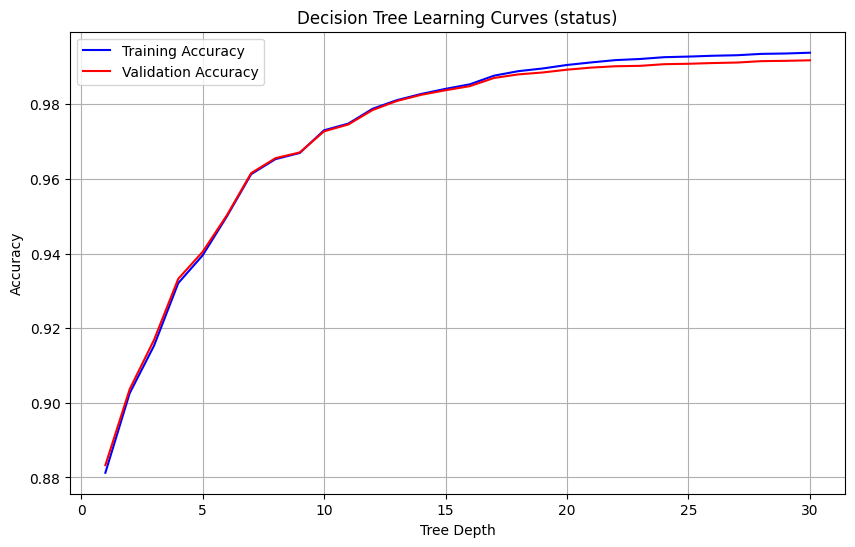

In [ ]:
print("\n" + "="*60)
print("Decision Tree Training Accuracy Curves (Version 1)")
print("="*60)

# For Attack Type
plot_tree_learning_curves(
    dt_model,  # Pass the full MultiOutputClassifier
    X_train,
    y_train,
    X_val,
    y_val,
    0  # First target ('Attack Type')
)

# For Status
plot_tree_learning_curves(
    dt_model,  # Pass the full MultiOutputClassifier
    X_train,
    y_train,
    X_val,
    y_val,
    1  # Second target ('status')
)

In [48]:
import joblib

# Load the saved model
dt_model_v1 = joblib.load("/content/drive/MyDrive/web-attack-detection/decision_tree_classifier.pkl")

# Verify model is loaded
print("Model loaded successfully!")

Model loaded successfully!


In [49]:
try:
    print(dt_model_v1)
    print("Model is defined!")
except NameError:
    print("Model not defined - reload or retrain the model.")

MultiOutputClassifier(estimator=DecisionTreeClassifier(max_depth=10,
                                                       random_state=42))
Model is defined!


In [52]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def calculate_confusion_metrics(y_true, y_pred):
    """Calculate TP, FP, TN, FN from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):  # Binary classification
        TN, FP, FN, TP = cm.ravel()
    else:  # Multi-class classification
        TP = np.diag(cm).sum()  # True Positives (correctly predicted for each class)
        FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
        FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
        TN = cm.sum() - (TP + FP.sum() + FN.sum())  # True Negatives

    return TP, FP.sum(), TN, FN.sum()

def print_confusion_metrics(y_true, y_pred, target_name):
    """Print confusion metrics for a target"""
    TP, FP, TN, FN = calculate_confusion_metrics(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{target_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")

In [53]:
# Get predictions
test_pred = dt_model_v1.predict(X_test)

# Print metrics for Attack Type (multi-class)
print("\n" + "="*60)
print("Attack Type Metrics (Multi-class)")
print("="*60)
print_confusion_metrics(y_test['Attack Type'], test_pred[:, 0], "Test Set")

# Print metrics for Status (binary)
print("\n" + "="*60)
print("Status Metrics (Binary)")
print("="*60)
print_confusion_metrics(y_test['status'], test_pred[:, 1], "Test Set")


Attack Type Metrics (Multi-class)

Test Set Metrics:
Accuracy: 0.9757
TP: 222797 | FP: 5560 | TN: -5560 | FN: 5560

Status Metrics (Binary)

Test Set Metrics:
Accuracy: 0.9728
TP: 173427 | FP: 5148 | TN: 48719 | FN: 1063


In [50]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name="Model"):
    """Enhanced evaluation with validation set metrics"""
    # Get predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # Helper function to calculate metrics
    def print_metrics(y_true, y_pred, dataset_name):
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)

        if cm.shape == (2, 2):  # Binary classification
            TN, FP, FN, TP = cm.ravel()
            print(f"{dataset_name} Metrics:")
            print(f"Accuracy: {acc:.4f}")
            print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")
        else:  # Multi-class (Attack Type)
            print(f"{dataset_name} Multi-class Accuracy: {acc:.4f}")

    # Training set evaluation
    print("\n" + "="*60)
    print(f"{name} - Training Set Evaluation")
    print_metrics(y_train['status'], train_pred[:, 1], "Training Binary (Status)")
    print_metrics(y_train['Attack Type'], train_pred[:, 0], "Training Multi-class (Attack Type)")

    # Validation set evaluation
    print("\n" + "="*60)
    print(f"{name} - Validation Set Evaluation")
    print_metrics(y_val['status'], val_pred[:, 1], "Validation Binary (Status)")
    print_metrics(y_val['Attack Type'], val_pred[:, 0], "Validation Multi-class (Attack Type)")

    # Test set evaluation
    print("\n" + "="*60)
    print(f"{name} - Test Set Evaluation")
    print_metrics(y_test['status'], test_pred[:, 1], "Test Binary (Status)")
    print_metrics(y_test['Attack Type'], test_pred[:, 0], "Test Multi-class (Attack Type)")

## Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Parameter grid for tuning
rf_param_grid = {
    'estimator__n_estimators': [50, 100],
    'estimator__max_depth': [10, 20],
    'estimator__min_samples_split': [2, 5]
}

# Train Random Forest for Dataset Version 1
rf_model_v1, rf_best_params_v1 = perform_hyperparameter_tuning(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    X_train,  # From Dataset Version 1
    y_train
)

print("Best Parameters:", rf_best_params_v1)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters: {'estimator__max_depth': 10, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50}
Best Parameters: {'estimator__max_depth': 10, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50}


Random Forest (V1) Train Accuracy- Attack Type: 0.9778, Status: 0.9829, Average: 0.9804
Random Forest (V1) Validation Accuracy- Attack Type: 0.9772, Status: 0.9828, Average: 0.98
Random Forest (V1) Test Accuracy- Attack Type: 0.9772, Status: 0.9825, Average: 0.9798

Classification Report for multi-class classification
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     53867
           1       0.97      1.00      0.98     28968
           2       1.00      0.97      0.98     28934
           3       1.00      1.00      1.00     29109
           4       1.00      0.98      0.99     29364
           5       0.99      0.99      0.99     29047
           6       0.98      0.93      0.96     29068

    accuracy                           0.98    228357
   macro avg       0.98      0.98      0.98    228357
weighted avg       0.98      0.98      0.98    228357


Classification Report for binary classification
              precision    recall 

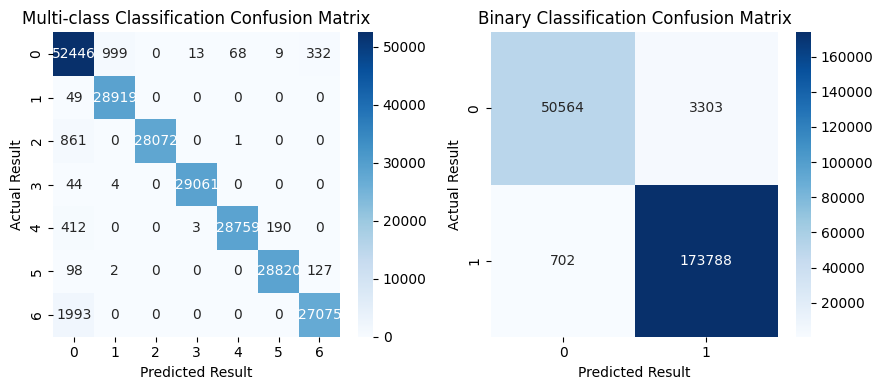

Random Forest V1 Training Time: 0h 6m 7s


In [11]:

# Save model
joblib.dump(rf_model_v1, "/content/drive/MyDrive/web-attack-detection/random_forest_v1.pkl")

# Evaluate metrics
check_metrics(rf_model_v1, "Random Forest (V1)", X_train, y_train, X_val, y_val, X_test, y_test)

# Time tracking
measure_time(time.time() - start_time, "Random Forest V1")


Random Forest Learning Curves (Version 1)


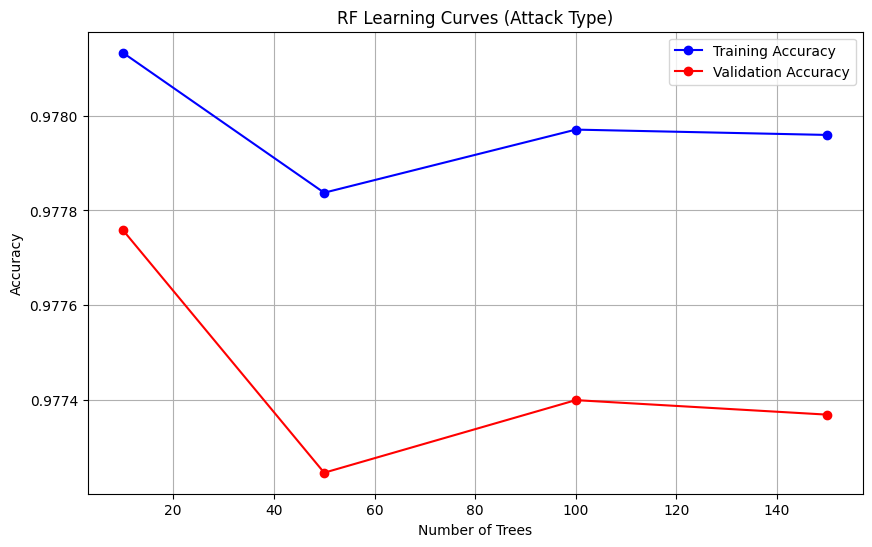

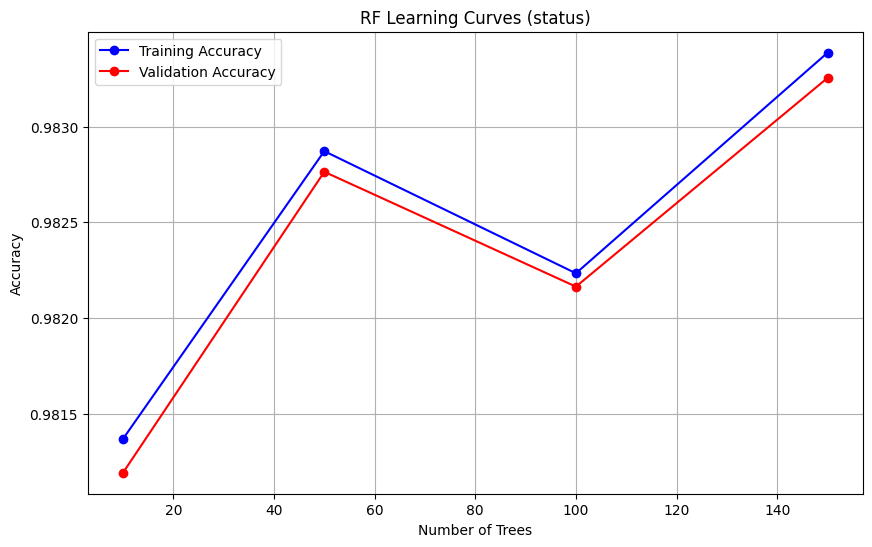

In [12]:
print("\n" + "="*60)
print("Random Forest Learning Curves (Version 1)")
print("="*60)

plot_rf_learning_curves(rf_model_v1, X_train, y_train, X_val, y_val, 0)  # Attack Type
plot_rf_learning_curves(rf_model_v1, X_train, y_train, X_val, y_val, 1)  # Status

In [42]:
import joblib

# Load the saved model
rf_model_v1 = joblib.load("/content/drive/MyDrive/web-attack-detection/random_forest_v1.pkl")

# Verify model is loaded
print("Model loaded successfully!")

Model loaded successfully!


In [43]:
try:
    print(rf_model_v1)
    print("Model is defined!")
except NameError:
    print("Model not defined - reload or retrain the model.")

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                       n_estimators=50,
                                                       random_state=42))
Model is defined!


In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def calculate_confusion_metrics(y_true, y_pred):
    """Calculate TP, FP, TN, FN from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):  # Binary classification
        TN, FP, FN, TP = cm.ravel()
    else:  # Multi-class classification
        TP = np.diag(cm).sum()  # True Positives (correctly predicted for each class)
        FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
        FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
        TN = cm.sum() - (TP + FP.sum() + FN.sum())  # True Negatives

    return TP, FP.sum(), TN, FN.sum()

def print_confusion_metrics(y_true, y_pred, target_name):
    """Print confusion metrics for a target"""
    TP, FP, TN, FN = calculate_confusion_metrics(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{target_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")

In [45]:
# Get predictions
test_pred = rf_model_v1.predict(X_test)

# Print metrics for Attack Type (multi-class)
print("\n" + "="*60)
print("Attack Type Metrics (Multi-class)")
print("="*60)
print_confusion_metrics(y_test['Attack Type'], test_pred[:, 0], "Test Set")

# Print metrics for Status (binary)
print("\n" + "="*60)
print("Status Metrics (Binary)")
print("="*60)
print_confusion_metrics(y_test['status'], test_pred[:, 1], "Test Set")


Attack Type Metrics (Multi-class)

Test Set Metrics:
Accuracy: 0.9772
TP: 223152 | FP: 5205 | TN: -5205 | FN: 5205

Status Metrics (Binary)

Test Set Metrics:
Accuracy: 0.9825
TP: 173788 | FP: 3303 | TN: 50564 | FN: 702


## Naive Bayes

In [16]:
def plot_nb_learning_curves(model, X_train, y_train, X_val, y_val, target_idx):
    """Plot learning curves for Naive Bayes (training size vs accuracy)"""
    train_sizes, train_scores, val_scores = learning_curve(
        model.estimators_[target_idx],
        X_train,
        y_train.iloc[:, target_idx],
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'b-o', label='Training Accuracy')
    plt.plot(train_sizes, np.mean(val_scores, axis=1), 'r-o', label='Validation Accuracy')
    plt.title(f'Naive Bayes Learning Curves ({y_train.columns[target_idx]})')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

Naive Bayes (Version 1) Train Accuracy- Attack Type: 0.616, Status: 0.8595, Average: 0.7377
Naive Bayes (Version 1) Validation Accuracy- Attack Type: 0.6148, Status: 0.8618, Average: 0.7383
Naive Bayes (Version 1) Test Accuracy- Attack Type: 0.6167, Status: 0.8608, Average: 0.7387

Classification Report for multi-class classification
              precision    recall  f1-score   support

           0       0.98      0.60      0.74     53867
           1       0.41      0.53      0.47     28968
           2       0.76      0.21      0.33     28934
           3       0.92      0.97      0.94     29109
           4       0.86      0.91      0.88     29364
           5       0.83      0.14      0.23     29047
           6       0.34      0.98      0.50     29068

    accuracy                           0.62    228357
   macro avg       0.73      0.62      0.59    228357
weighted avg       0.76      0.62      0.60    228357


Classification Report for binary classification
              prec

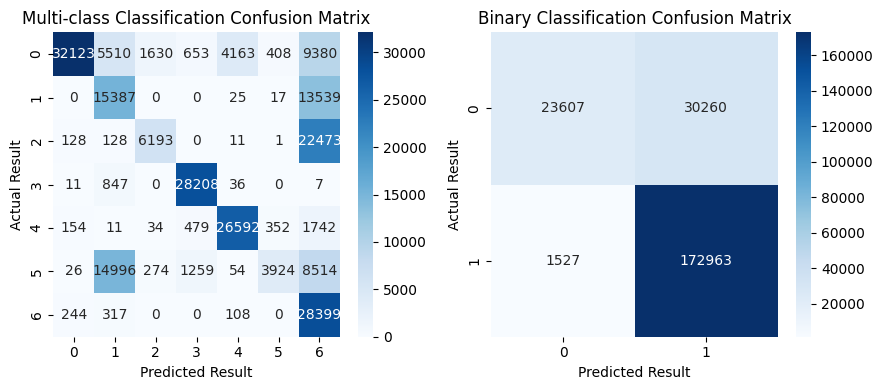

Naive Bayes V1 Training Time: 0h 0m 3s

Naive Bayes Learning Curves (Version 1)


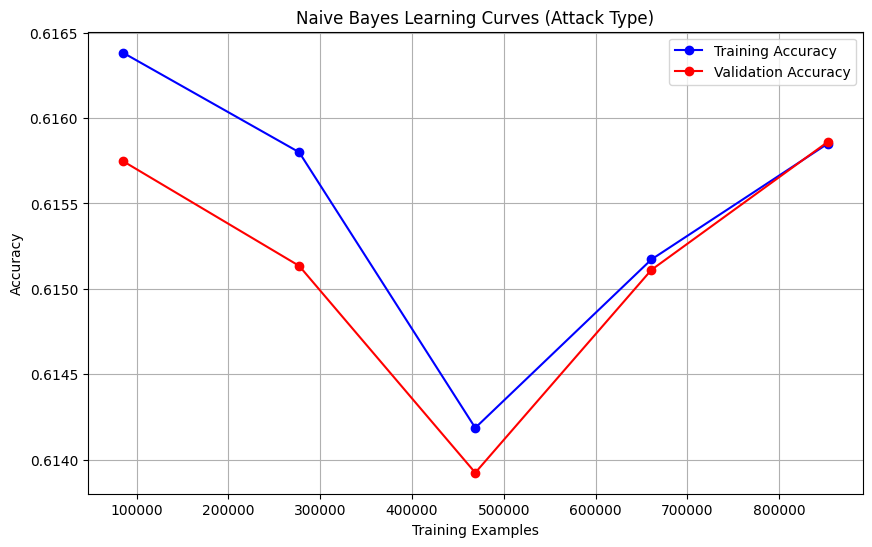

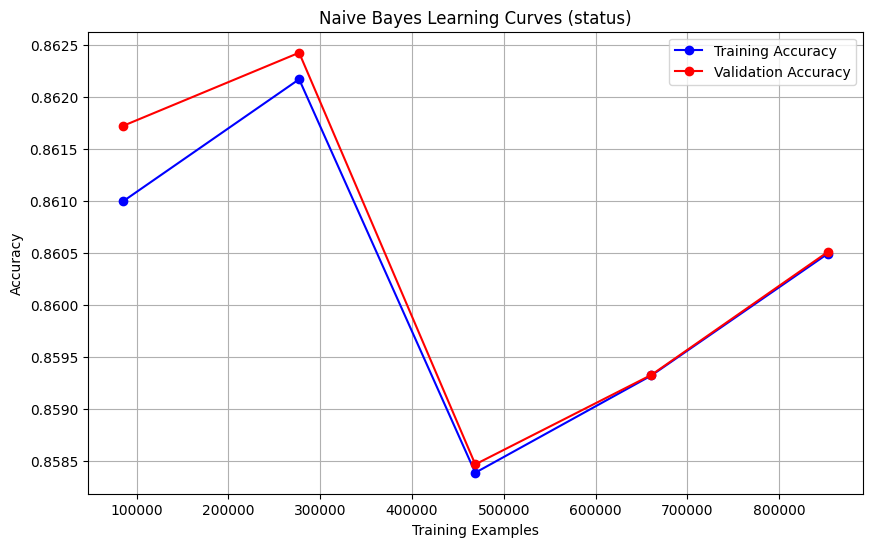

In [21]:
start_time = time.time()
nb_model_v1 = MultiOutputClassifier(GaussianNB())
nb_model_v1.fit(X_train, y_train)

check_metrics(
    nb_model_v1,
    "Naive Bayes (Version 1)",
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
)

measure_time(time.time() - start_time, "Naive Bayes V1")

# Save Model
joblib.dump(nb_model_v1, "/content/drive/MyDrive/web-attack-detection/naive_bayes_v1.pkl")

# Plot Learning Curves
print("\n" + "="*60)
print("Naive Bayes Learning Curves (Version 1)")
print("="*60)

plot_nb_learning_curves(nb_model_v1, X_train, y_train, X_val, y_val, 0)  # Attack Type
plot_nb_learning_curves(nb_model_v1, X_train, y_train, X_val, y_val, 1)  # Status

In [38]:
import joblib

# Load the saved model
nb_model_v1 = joblib.load("/content/drive/MyDrive/web-attack-detection/naive_bayes_v1.pkl")

# Verify model is loaded
print("Model loaded successfully!")

Model loaded successfully!


In [39]:
try:
    print(nb_model_v1)
    print("Model is defined!")
except NameError:
    print("Model not defined - reload or retrain the model.")

MultiOutputClassifier(estimator=GaussianNB())
Model is defined!


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def calculate_confusion_metrics(y_true, y_pred):
    """Calculate TP, FP, TN, FN from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):  # Binary classification
        TN, FP, FN, TP = cm.ravel()
    else:  # Multi-class classification
        TP = np.diag(cm).sum()  # True Positives (correctly predicted for each class)
        FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
        FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
        TN = cm.sum() - (TP + FP.sum() + FN.sum())  # True Negatives

    return TP, FP.sum(), TN, FN.sum()

def print_confusion_metrics(y_true, y_pred, target_name):
    """Print confusion metrics for a target"""
    TP, FP, TN, FN = calculate_confusion_metrics(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{target_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")

In [41]:
# Get predictions
test_pred = nb_model_v1.predict(X_test)

# Print metrics for Attack Type (multi-class)
print("\n" + "="*60)
print("Attack Type Metrics (Multi-class)")
print("="*60)
print_confusion_metrics(y_test['Attack Type'], test_pred[:, 0], "Test Set")

# Print metrics for Status (binary)
print("\n" + "="*60)
print("Status Metrics (Binary)")
print("="*60)
print_confusion_metrics(y_test['status'], test_pred[:, 1], "Test Set")


Attack Type Metrics (Multi-class)

Test Set Metrics:
Accuracy: 0.6167
TP: 140826 | FP: 87531 | TN: -87531 | FN: 87531

Status Metrics (Binary)

Test Set Metrics:
Accuracy: 0.8608
TP: 172963 | FP: 30260 | TN: 23607 | FN: 1527


*****
# Model Training on Dataset Version 2 (safe_same_malicious_balanced)
**Dataset Details:**
- 2602112 samples
- 30 features
- 2 targets
  - 7 different class (1 safe, 6 diffrent malicious)
  - binary class (0-safe, 1-malicous)

In [7]:
# Define dataset path
v2_path = "/content/drive/MyDrive/Anytime/okay/PREPROCESS DATASETS/safe_same_and_malicious_balanced"

# Load data
X_train_v2 = pd.read_csv(f"{v2_path}/X_train.csv")
X_val_v2 = pd.read_csv(f"{v2_path}/X_val.csv")
X_test_v2 = pd.read_csv(f"{v2_path}/X_test.csv")
y_train_v2 = pd.read_csv(f"{v2_path}/y_train.csv")
y_val_v2 = pd.read_csv(f"{v2_path}/y_val.csv")
y_test_v2 = pd.read_csv(f"{v2_path}/y_test.csv")

# Verify
print(f"Version 2 Dataset Size: {X_train_v2.shape[0]:,} samples")

Version 2 Dataset Size: 1,821,478 samples


In [23]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
  start = time.time()
  train_base_model(model, name, X_train, y_train, X_test, y_test)
  end = time.time()
  measure_time((end-start), name)

Decision Tree Train Accuracy- Attack Type: 0.9955, Status: 0.9956, Average: 0.9955
Decision Tree Test Accuracy- Attack Type: 0.9906, Status: 0.9936, Average: 0.9921

Decision Tree - Training Set Evaluation
Training Binary (Status) Metrics:
Accuracy: 0.9956
TP: 810925 | FP: 2485 | TN: 250086 | FN: 2170
Training Multi-class (Attack Type) Multi-class Accuracy: 0.9955

Decision Tree - Validation Set Evaluation
Validation Binary (Status) Metrics:
Accuracy: 0.9934
TP: 174167 | FP: 793 | TN: 52679 | FN: 718
Validation Multi-class (Attack Type) Multi-class Accuracy: 0.9904

Decision Tree - Test Set Evaluation
Test Binary (Status) Metrics:
Accuracy: 0.9936
TP: 173780 | FP: 755 | TN: 53112 | FN: 710
Test Multi-class (Attack Type) Multi-class Accuracy: 0.9906
Decision Tree Training Time: 0h 1m 14s
Random Forest Train Accuracy- Attack Type: 0.9954, Status: 0.9956, Average: 0.9955
Random Forest Test Accuracy- Attack Type: 0.9913, Status: 0.9942, Average: 0.9928

Random Forest - Training Set Evaluat

## Decision Tree

In [ ]:
# copy and paste the same code but run again

In [24]:
# Use same parameter grid as Version 1
dt_param_grid = {
    'estimator__max_depth': [10, 20, 30, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Tune on Version 2 data
dt_model_v2, dt_best_params_v2 = perform_hyperparameter_tuning(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    X_train_v2,
    y_train_v2
)

print("Best Parameters for Version 2:", dt_best_params_v2)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}
Best Parameters for Version 2: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}


Decision Tree (Version 2) Train Accuracy- Attack Type: 0.966, Status: 0.9644, Average: 0.9652
Decision Tree (Version 2) Validation Accuracy- Attack Type: 0.9659, Status: 0.964, Average: 0.9649
Decision Tree (Version 2) Test Accuracy- Attack Type: 0.9657, Status: 0.9642, Average: 0.965

Classification Report for multi-class classification
              precision    recall  f1-score   support

           0       0.98      0.97      0.97    216194
           1       0.87      0.99      0.93     28982
           2       1.00      0.96      0.98     29106
           3       1.00      1.00      1.00     28933
           4       0.96      0.94      0.95     29308
           5       0.95      0.99      0.97     28938
           6       0.95      0.90      0.93     28856

    accuracy                           0.97    390317
   macro avg       0.96      0.96      0.96    390317
weighted avg       0.97      0.97      0.97    390317


Classification Report for binary classification
              

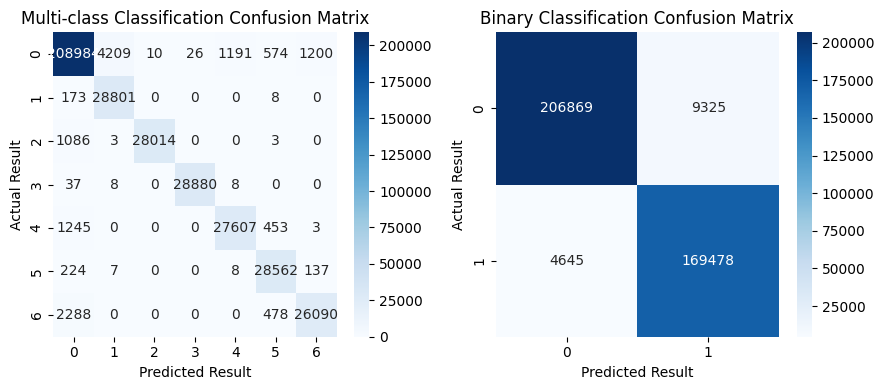

In [25]:
check_metrics(
    dt_model_v2,
    "Decision Tree (Version 2)",
    X_train_v2,
    y_train_v2,
    X_val_v2,
    y_val_v2,
    X_test_v2,
    y_test_v2
)


Decision Tree Learning Curves (Version 2)


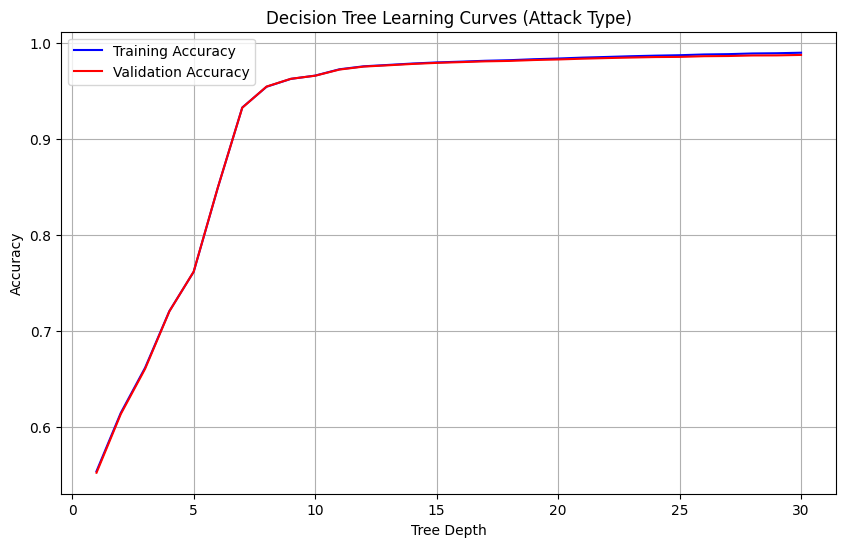

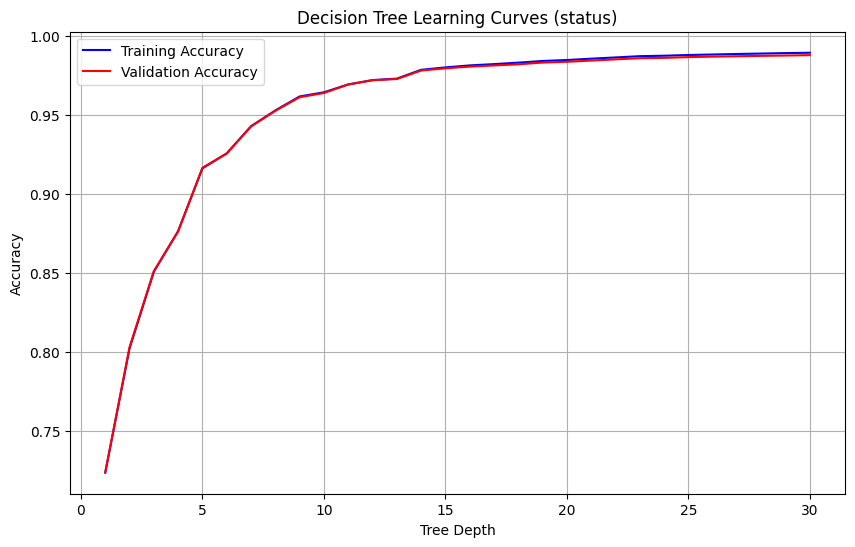

In [26]:
print("\n" + "="*60)
print("Decision Tree Learning Curves (Version 2)")
print("="*60)

plot_tree_learning_curves(dt_model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, 0)  # Attack Type
plot_tree_learning_curves(dt_model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, 1)  # Status

In [ ]:
joblib.dump(dt_model_v2, "/content/drive/MyDrive/web-attack-detection/decision_tree_v2.pkl")

In [34]:
import joblib

# Load the saved model
dt_model_v2 = joblib.load("/content/drive/MyDrive/web-attack-detection/decision_tree_v2.pkl")

# Verify model is loaded
print("Model loaded successfully!")

Model loaded successfully!


In [35]:
try:
    print(dt_model_v2)
    print("Model is defined!")
except NameError:
    print("Model not defined - reload or retrain the model.")

MultiOutputClassifier(estimator=DecisionTreeClassifier(max_depth=10,
                                                       random_state=42))
Model is defined!


In [36]:
def calculate_confusion_metrics(y_true, y_pred):
    """Calculate TP, FP, TN, FN from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):  # Binary classification
        TN, FP, FN, TP = cm.ravel()
    else:  # Multi-class classification
        TP = np.diag(cm).sum()  # True Positives (correctly predicted for each class)
        FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
        FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
        TN = cm.sum() - (TP + FP.sum() + FN.sum())  # True Negatives

    return TP, FP.sum(), TN, FN.sum()

def print_confusion_metrics(y_true, y_pred, target_name):
    """Print confusion metrics for a target"""
    TP, FP, TN, FN = calculate_confusion_metrics(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{target_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")

In [37]:
# Get predictions
test_pred = dt_model_v2.predict(X_test_v2)

# Print metrics for Attack Type (multi-class)
print("\n" + "="*60)
print("Attack Type Metrics (Multi-class)")
print("="*60)
print_confusion_metrics(y_test_v2['Attack Type'], test_pred[:, 0], "Test Set")

# Print metrics for Status (binary)
print("\n" + "="*60)
print("Status Metrics (Binary)")
print("="*60)
print_confusion_metrics(y_test_v2['status'], test_pred[:, 1], "Test Set")


Attack Type Metrics (Multi-class)

Test Set Metrics:
Accuracy: 0.9657
TP: 376938 | FP: 13379 | TN: -13379 | FN: 13379

Status Metrics (Binary)

Test Set Metrics:
Accuracy: 0.9642
TP: 169478 | FP: 9325 | TN: 206869 | FN: 4645


## Random Forest

In [8]:
# Same parameter grid as Version 1
rf_param_grid = {
    'estimator__n_estimators': [50, 100],
    'estimator__max_depth': [10, 20],
    'estimator__min_samples_split': [2, 5]
}

# Tune on Version 2 data
start_time = time.time()
rf_model_v2, rf_best_params_v2 = perform_hyperparameter_tuning(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    X_train_v2,
    y_train_v2
)
print("Best Parameters (V2):", rf_best_params_v2)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters: {'estimator__max_depth': 10, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50}
Best Parameters (V2): {'estimator__max_depth': 10, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50}


Random Forest (Version 2) Train Accuracy- Attack Type: 0.9764, Status: 0.9771, Average: 0.9767
Random Forest (Version 2) Validation Accuracy- Attack Type: 0.976, Status: 0.9768, Average: 0.9764
Random Forest (Version 2) Test Accuracy- Attack Type: 0.9761, Status: 0.9768, Average: 0.9764

Classification Report for multi-class classification
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216194
           1       0.93      0.95      0.94     28982
           2       1.00      0.97      0.98     29106
           3       1.00      1.00      1.00     28933
           4       1.00      0.97      0.98     29308
           5       0.99      0.99      0.99     28938
           6       0.96      0.92      0.94     28856

    accuracy                           0.98    390317
   macro avg       0.98      0.97      0.97    390317
weighted avg       0.98      0.98      0.98    390317


Classification Report for binary classification
            

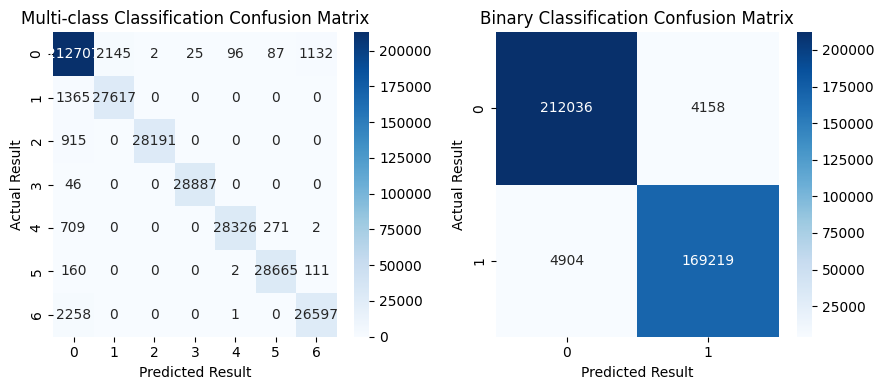

In [9]:
check_metrics(
    rf_model_v2,
    "Random Forest (Version 2)",
    X_train_v2,
    y_train_v2,
    X_val_v2,
    y_val_v2,
    X_test_v2,
    y_test_v2
)


Random Forest Learning Curves (Version 2)


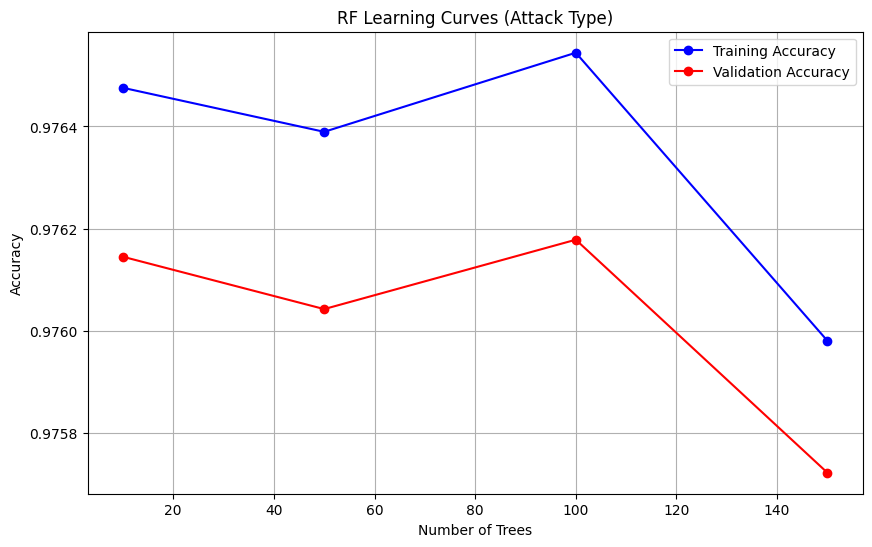

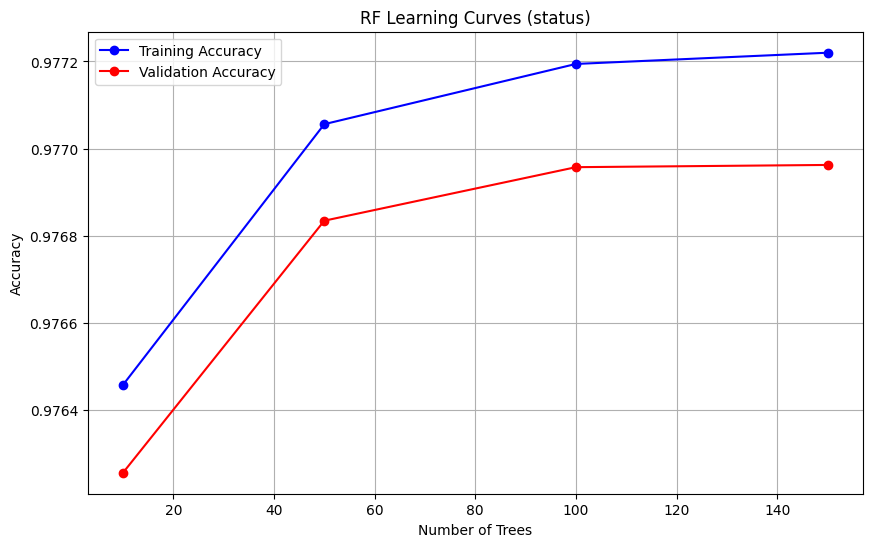

In [10]:
print("\n" + "="*60)
print("Random Forest Learning Curves (Version 2)")
print("="*60)

plot_rf_learning_curves(rf_model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, 0)  # Attack Type
plot_rf_learning_curves(rf_model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, 1)  # Status

In [25]:
def calculate_confusion_metrics(y_true, y_pred):
    """Calculate TP, FP, TN, FN from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):  # Binary classification
        TN, FP, FN, TP = cm.ravel()
    else:  # Multi-class classification
        TP = np.diag(cm).sum()  # True Positives (correctly predicted for each class)
        FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
        FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
        TN = cm.sum() - (TP + FP.sum() + FN.sum())  # True Negatives

    return TP, FP.sum(), TN, FN.sum()

def print_confusion_metrics(y_true, y_pred, target_name):
    """Print confusion metrics for a target"""
    TP, FP, TN, FN = calculate_confusion_metrics(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{target_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")

In [26]:
# Get predictions
train_pred = rf_model_v2.predict(X_train_v2)
val_pred = rf_model_v2.predict(X_val_v2)
test_pred = rf_model_v2.predict(X_test_v2)

# Print metrics for Attack Type (multi-class)
print("\n" + "="*60)
print("Attack Type Metrics (Multi-class)")
print("="*60)
print_confusion_metrics(y_test_v2['Attack Type'], test_pred[:, 0], "Test Set")

# Print metrics for Status (binary)
print("\n" + "="*60)
print("Status Metrics (Binary)")
print("="*60)
print_confusion_metrics(y_test_v2['status'], test_pred[:, 1], "Test Set")


Attack Type Metrics (Multi-class)

Test Set Metrics:
Accuracy: 0.9761
TP: 380990 | FP: 9327 | TN: -9327 | FN: 9327

Status Metrics (Binary)

Test Set Metrics:
Accuracy: 0.9768
TP: 169219 | FP: 4158 | TN: 212036 | FN: 4904


In [27]:
joblib.dump(rf_model_v2, "/content/drive/MyDrive/web-attack-detection/random_forest_v2.pkl")

['/content/drive/MyDrive/web-attack-detection/random_forest_v2.pkl']

## Naive Bayes

In [14]:
def plot_nb_learning_curves(model, X_train, y_train, X_val, y_val, target_idx):
    """Plot learning curves for Naive Bayes"""
    from sklearn.model_selection import learning_curve
    import numpy as np

    train_sizes, train_scores, val_scores = learning_curve(
        model.estimators_[target_idx],
        X_train,
        y_train.iloc[:, target_idx],
        cv=3,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'b-o', label='Training Accuracy')
    plt.plot(train_sizes, np.mean(val_scores, axis=1), 'r-o', label='Validation Accuracy')
    plt.title(f'Naive Bayes Learning Curves ({y_train.columns[target_idx]})')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

Naive Bayes (Version 2) Train Accuracy- Attack Type: 0.5945, Status: 0.692, Average: 0.6433
Naive Bayes (Version 2) Validation Accuracy- Attack Type: 0.593, Status: 0.6921, Average: 0.6426
Naive Bayes (Version 2) Test Accuracy- Attack Type: 0.5925, Status: 0.69, Average: 0.6413

Classification Report for multi-class classification
              precision    recall  f1-score   support

           0       1.00      0.57      0.72    216194
           1       0.29      0.54      0.37     28982
           2       0.47      0.21      0.30     29106
           3       0.87      0.97      0.92     28933
           4       0.54      0.91      0.68     29308
           5       0.66      0.14      0.23     28938
           6       0.25      0.97      0.40     28856

    accuracy                           0.59    390317
   macro avg       0.58      0.62      0.52    390317
weighted avg       0.78      0.59      0.62    390317


Classification Report for binary classification
              precisi

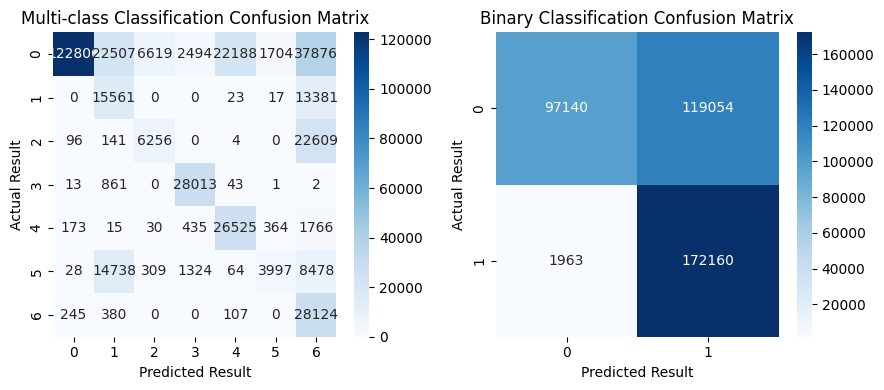

Naive Bayes V2 Training Time: 0h 0m 11s


['/content/drive/MyDrive/web-attack-detection/naive_bayes_v2.pkl']

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier

# Train Model
start_time = time.time()
nb_model_v2 = MultiOutputClassifier(GaussianNB())
nb_model_v2.fit(X_train_v2, y_train_v2)

# Evaluate
check_metrics(
    nb_model_v2,
    "Naive Bayes (Version 2)",
    X_train_v2,
    y_train_v2,
    X_val_v2,
    y_val_v2,
    X_test_v2,
    y_test_v2
)

# Track Time
measure_time(time.time() - start_time, "Naive Bayes V2")

# Save Model
joblib.dump(nb_model_v2, "/content/drive/MyDrive/web-attack-detection/naive_bayes_v2.pkl")


Naive Bayes Learning Curves (Version 2)


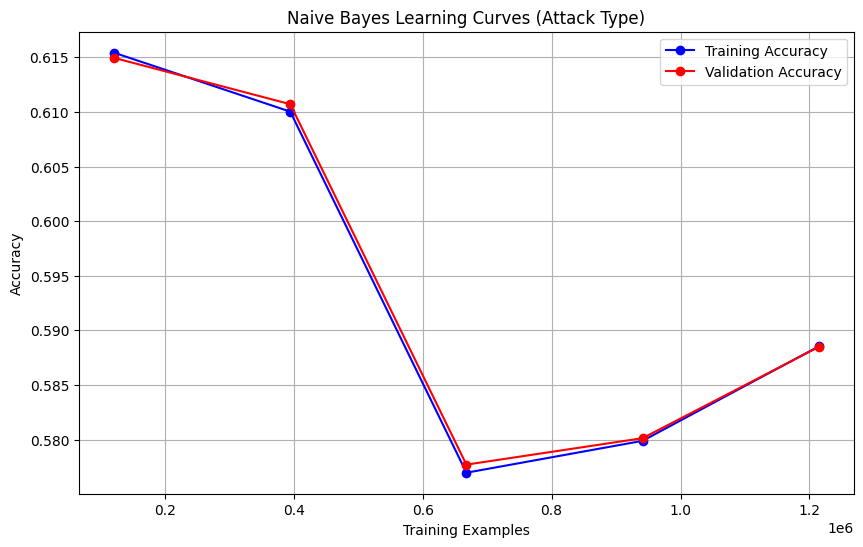

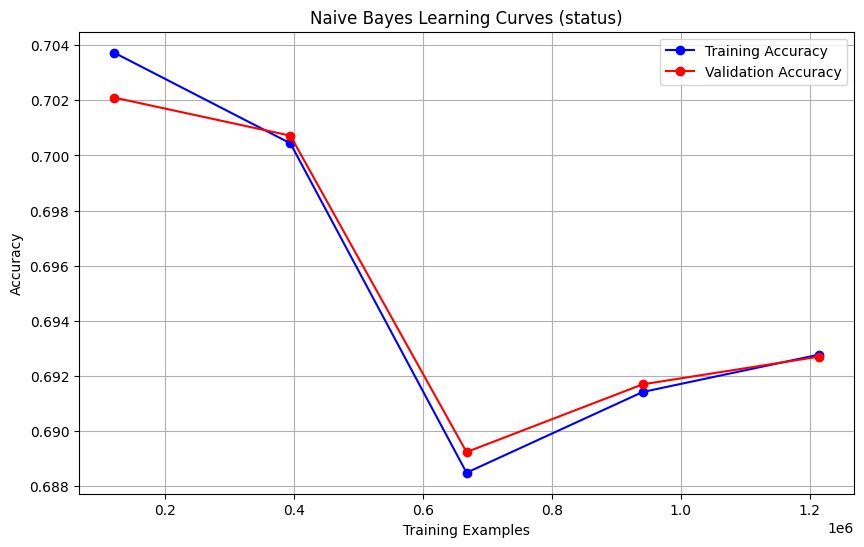

In [15]:
print("\n" + "="*60)
print("Naive Bayes Learning Curves (Version 2)")
print("="*60)

plot_nb_learning_curves(nb_model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, 0)  # Attack Type
plot_nb_learning_curves(nb_model_v2, X_train_v2, y_train_v2, X_val_v2, y_val_v2, 1)  # Status

In [16]:
joblib.dump(nb_model_v2, "/content/drive/MyDrive/web-attack-detection/naive_bayes_v2.pkl")

['/content/drive/MyDrive/web-attack-detection/naive_bayes_v2.pkl']

In [23]:
def calculate_confusion_metrics(y_true, y_pred):
    """Calculate TP, FP, TN, FN from confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):  # Binary classification
        TN, FP, FN, TP = cm.ravel()
    else:  # Multi-class classification
        TP = np.diag(cm).sum()  # True Positives (correctly predicted for each class)
        FP = cm.sum(axis=0) - np.diag(cm)  # False Positives
        FN = cm.sum(axis=1) - np.diag(cm)  # False Negatives
        TN = cm.sum() - (TP + FP.sum() + FN.sum())  # True Negatives

    return TP, FP.sum(), TN, FN.sum()

def print_confusion_metrics(y_true, y_pred, target_name):
    """Print confusion metrics for a target"""
    TP, FP, TN, FN = calculate_confusion_metrics(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{target_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")

In [24]:
# Get predictions
train_pred = nb_model_v2.predict(X_train_v2)
val_pred = nb_model_v2.predict(X_val_v2)
test_pred = nb_model_v2.predict(X_test_v2)

# Print metrics for Attack Type (multi-class)
print("\n" + "="*60)
print("Attack Type Metrics (Multi-class)")
print("="*60)
print_confusion_metrics(y_test_v2['Attack Type'], test_pred[:, 0], "Test Set")

# Print metrics for Status (binary)
print("\n" + "="*60)
print("Status Metrics (Binary)")
print("="*60)
print_confusion_metrics(y_test_v2['status'], test_pred[:, 1], "Test Set")


Attack Type Metrics (Multi-class)

Test Set Metrics:
Accuracy: 0.5925
TP: 231282 | FP: 159035 | TN: -159035 | FN: 159035

Status Metrics (Binary)

Test Set Metrics:
Accuracy: 0.6900
TP: 172160 | FP: 119054 | TN: 97140 | FN: 1963
